# Homework 2: Methods for Regression
# Air Quality Index Prediction using Regression Methods

**IEEE Conference Paper Format**

This notebook follows the IEEE paper structure:
- Abstract
- Introduction
- Methods
- Results

## Abstract

*To be completed: Provide a short and informative overview of the regression methods applied, the problem being solved, and key performance results obtained.*

## 1. Introdução

O presente trabalho concentra-se na análise e modelagem de dados de qualidade do ar, utilizando o conjunto de dados Air Quality UCI (2004 - 2005). Esta base é crucial por oferecer um registro detalhado para o estudo da poluição em ambientes urbanos.

O dataset abrange 9.358 registros horários e é composto por um total de 13 variáveis de entrada e saída, estruturadas da seguinte forma:

Sensores de Óxido Metálico (MOx): O núcleo dos dados de entrada é fornecido por 5 sensores de óxido metálico de estágio único (identificados como PT08.S1 a PT08.S5).

- Variáveis Meteorológicas: Três variáveis de meteorologia (Temperatura, Umidade Relativa e Umidade Absoluta) são incluídas para contabilizar o forte efeito contextual nas leituras dos sensores.

- Variáveis-Alvo (Ground Truth - GT): O conjunto é complementado por 5 variáveis Ground Truth, captadas por instrumentos de referência, que servem para validar e calibrar a assertividade das leituras dos sensores de baixo custo.
Em resumo, a análise considera 8 variáveis de métrica (leituras de sensores e meteorologia), 1 variável temporal (registro horário) e 5 variáveis GT (concentrações reais de poluentes).

- A Meteorologia é a ciência que estuda a atmosfera terrestre e os fenômenos que ocorrem nela, com o principal objetivo de prever o tempo e o clima

fundamental destacar a natureza dos sensores utilizados. Os Sensores de Óxido Metálico (MOx) são dispositivos que operam medindo a resistência elétrica de um material semicondutor (óxido metálico) quando este entra em contato com um gás específico. Essa mudança de resistência é convertida em uma medida de concentração do poluente.

Para otimizar o processo de modelagem preditiva e mitigar a redundância entre os preditores, aplicou-se a técnica de Análise de Componentes Principais (PCA). Após a aplicação da PCA, o conjunto de dados foi eficientemente reduzido a 2 ou 3 componentes principais, que, em conjunto, são capazes de preservar entre 77,5% e 92,1% da variância total das variáveis preditoras originais. Essa redução de dimensionalidade é crucial para melhorar a robustez e a interpretabilidade do modelo final.

O objetivo da modelagem preditiva será validar o funcionamento dos sensores (mox) de baixo custo e verificar se artefatos de humidade e temperatura alteram a precisao destes sensores ao comparalos com os valores GT, excluindo-se os valores do sensor nmhc pois a quantidade de dados ausentes é grande demais para determinarmos validação (>90%) 

O presente trabalho se propõe a desenvolver e validar um modelo de Inteligência Artificial para a calibração de sensores de baixo custo do tipo Óxido Metálico (MOx), utilizando o extenso dataset Air Quality UCI (2004-2005), que contém 9.358 registros horários. O principal foco metodológico é mitigar o impacto de artefatos meteorológicos (Temperatura e Umidade) nas leituras dos 5 sensores MOx, comparando os resultados preditos com os valores de referência Ground Truth (GT) dos poluentes (CO, $\text{NO}_x$, $\text{NO}_2$, $\text{C}_6\text{H}_6$). Para otimizar a modelagem, foi aplicado o PCA para redução de dimensionalidade, preservando alta porcentagem da variância, e foi criado o Índice de Poluição Composto (CPI), padronizado via Z-score, para fornecer uma variável-alvo agregada de poluição.



## 1.1 Objetivos propostos para o trabalho 
O objetivo principal deste estudo de modelagem preditiva é realizar a validação cruzada e a calibração dos sensores de baixo custo do tipo Óxido Metálico (MOx), utilizando dados de referência (Ground Truth - GT).

- Avaliar a Precisão e Confiabilidade dos Sensores MOx: Determinar a capacidade dos sensores de baixo custo (PT08.S1 a PT08.S5) em estimar com precisão as concentrações reais de poluentes (variáveis GT), através da comparação direta entre os valores preditos pelo modelo de IA e os valores de referência.

- Quantificar o Impacto do Contexto Meteorológico (Artefatos): Investigar e quantificar o grau em que as variáveis meteorológicas (Temperatura e Umidade Relativa/Absoluta) introduzem artefatos e vieses nas leituras dos sensores MOx. O modelo preditivo será utilizado para isolar e corrigir esses efeitos, validando a hipótese de que a inclusão dessas variáveis de contexto é essencial para a calibração precisa.

- Estabelecer um Conjunto de Dados de Saída Robusto: Em decorrência de alta taxa de dados ausentes (superior a 90%) na variável NMHC (Hidrocarbonetos Não Metânicos), esta variável será excluída da análise preditiva e de validação, focando a modelagem e a validação em um subconjunto de poluentes GT com integridade de dados suficiente.

## 1.2 Pré-processamento

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import zscore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import norm


In [2]:


def plot_time_hist_box(df, save_name=None):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    palette = sns.color_palette("viridis", 6)
    
    fig, axes = plt.subplots(
        len(numeric_cols), 3,
        figsize=(16, len(numeric_cols) * 1.8),
        gridspec_kw={"width_ratios": [4.7, 1.2, 0.6]}
    )
    
    fig.suptitle("Resumo — Série Temporal, Distribuição e Boxplot", fontsize=20, weight="bold", y=0.97)

    for i, col in enumerate(numeric_cols):
        ax_ts, ax_hist, ax_box = axes[i]

        df[col].plot(ax=ax_ts, lw=0.9, color=palette[2])
        ax_ts.set_ylabel(col, fontsize=10, weight="bold")
        ax_ts.set_xlabel("")
        ax_ts.grid(True, alpha=0.25, linestyle="--")
        ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%m-%y"))
        ax_ts.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax_ts.get_xticklabels(), rotation=45, ha="right", fontsize=9)

        na_mask = df[col].isna()
        if na_mask.sum() > 0:
            ax_ts.scatter(df.index[na_mask], [df[col].mean()] * na_mask.sum(), color=palette[4], s=8)

        data = df[col].dropna()
        sns.histplot(data, bins=10, ax=ax_hist, color=palette[1], edgecolor=palette[3], alpha=0.7)

        x = np.linspace(data.min(), data.max(), 200)
        mu, sigma = data.mean(), data.std()
        ax_hist.plot(
            x,
            norm.pdf(x, mu, sigma) * len(data) * (data.max() - data.min()) / 10,
            color=palette[5],
            lw=1.5,
            linestyle="--"
        )

        ax_hist.tick_params(axis="both", labelsize=8)
        ax_hist.set_xlabel("Valor", fontsize=9)
        ax_hist.set_ylabel("Freq.", fontsize=9)
        ax_hist.grid(True, alpha=0.15, linestyle=":")

        sns.boxplot(y=data, ax=ax_box, color=palette[2], linewidth=1)
        ax_box.set_xlabel("")
        ax_box.set_ylabel("")
        ax_box.tick_params(axis="y", labelsize=8)
        ax_box.grid(True, alpha=0.1, linestyle=":")

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()


In [3]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
%matplotlib inline

# Tema e parâmetros globais
palette_theme = "ch:start=.2,rot=-.3"
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.figsize": (20, 6),
    "axes.titlesize": 18,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.autolayout": True,
    "figure.titleweight": "bold",  
    "axes.titlepad": 20
})

# Diretório de figuras
PATH_FIG = "./figures"
os.makedirs(PATH_FIG, exist_ok=True)

# Paleta única do projeto
palette = sns.color_palette(palette_theme, n_colors=6)

# Função simples de salvar figura (uma linha só, usada muitas vezes)
savefig = lambda name: plt.savefig(os.path.join(PATH_FIG, f"{name}.png"), bbox_inches="tight")

#### 2.3 Carregando dataset.

In [4]:
# Caminho do CSV (ajuste se necessário)
data_path = "../database/air_quality_uci.csv"

# Leitura
air_quality = pd.read_csv(
    data_path,
    sep=";",
    decimal=",",
    na_values=-200,
    parse_dates={"datetime": ["Date", "Time"]},
    date_format="%d/%m/%Y %H.%M.%S",
    index_col="datetime"
)

# Garantia do tipo datetime
air_quality.index = pd.to_datetime(air_quality.index, format="%d/%m/%Y %H.%M.%S", errors="coerce")

# Remoção de colunas vazias finais (presentes no dataset original)
air_quality = air_quality.iloc[:, :-2]

# Apagar linhas duplicadas
dups = air_quality.duplicated().sum()
air_quality = air_quality.drop_duplicates()
print(f"Duplicatas removidas: {dups}")

# Define o índice temporal ordenado
air_quality = air_quality.sort_index()

# Exibir 5 linhas aleatórias para verificar se foi carregado corretamente
print(f"Dataset shape: {air_quality.shape}")
air_quality.sample(5)



Duplicatas removidas: 145
Dataset shape: (9326, 13)


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-11 13:00:00,1.9,1286.0,63.0,7.3,869.0,146.0,1162.0,112.0,1537.0,799.0,8.3,76.4,0.8393
2004-03-16 18:00:00,3.4,1447.0,237.0,17.8,1235.0,184.0,859.0,139.0,1778.0,1296.0,23.9,25.7,0.7519
2004-05-02 02:00:00,0.9,938.0,NaN,5.5,789.0,38.0,989.0,55.0,1536.0,864.0,16.4,62.2,1.1507
2005-03-01 02:00:00,0.4,736.0,NaN,0.6,453.0,39.0,1498.0,37.0,602.0,268.0,0.2,40.6,0.2566
2004-04-17 03:00:00,NaN,1057.0,NaN,5.1,768.0,NaN,958.0,NaN,1527.0,884.0,12.4,82.4,1.1848


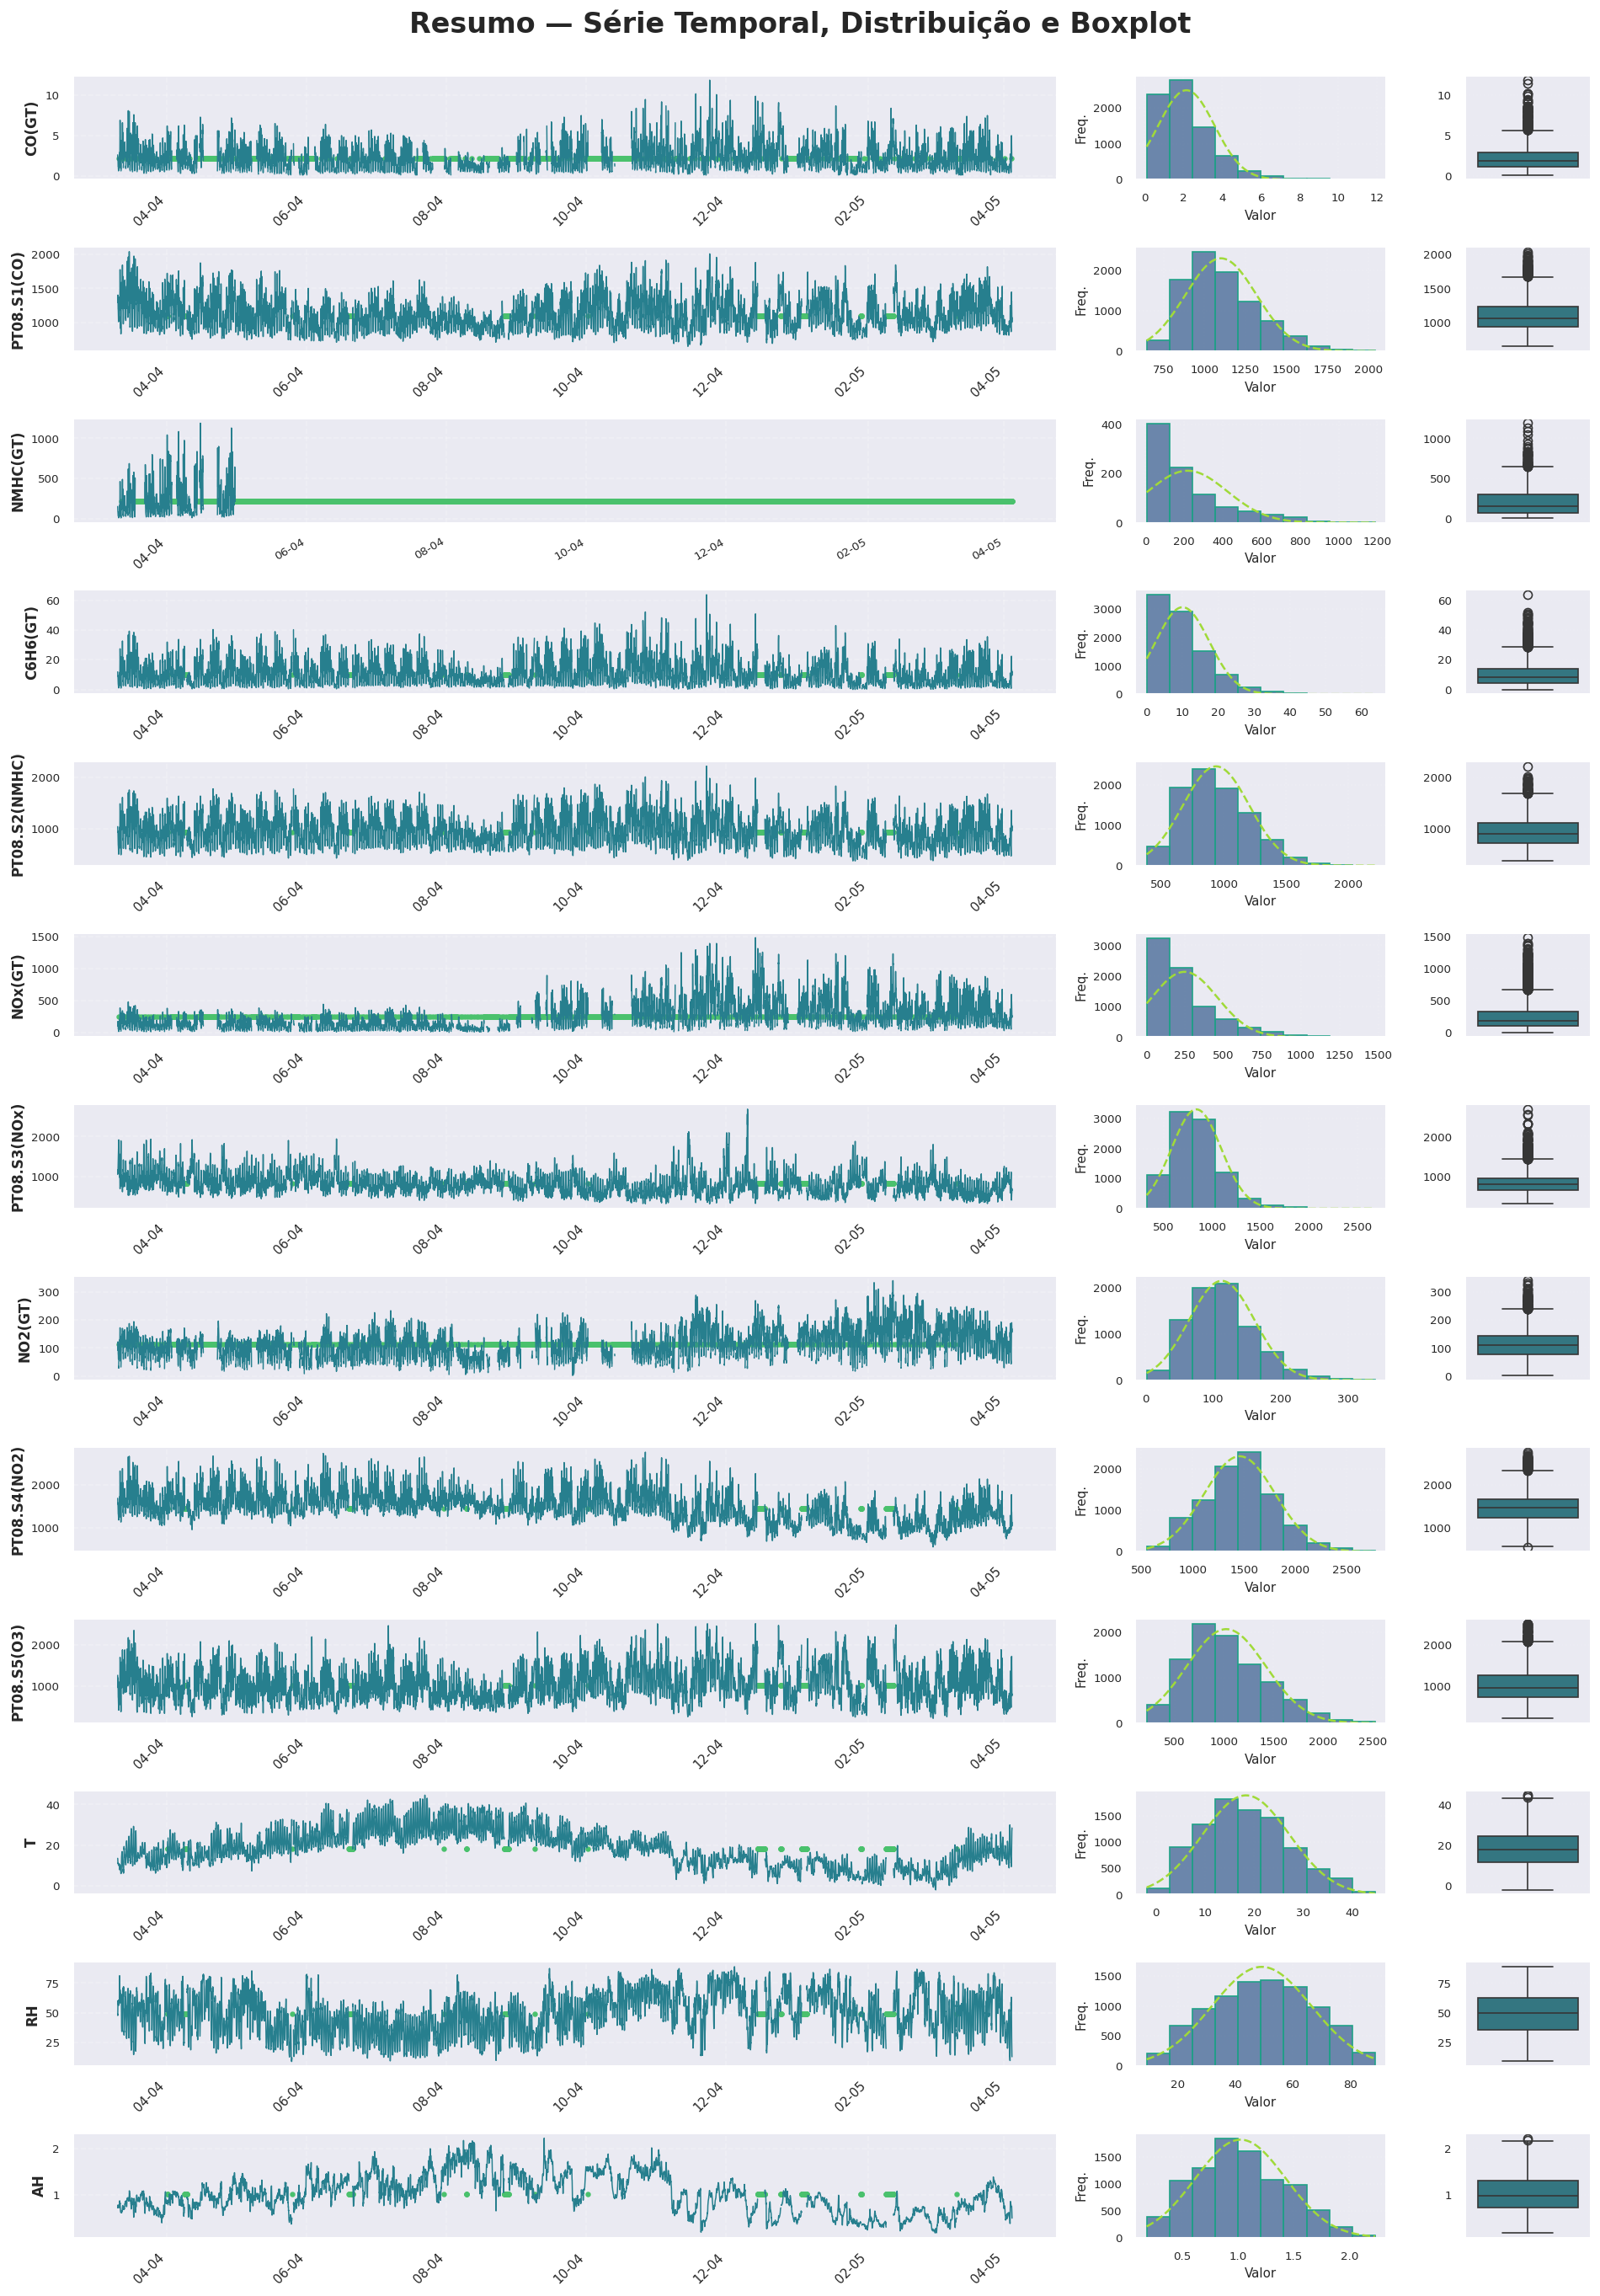

In [5]:
plot_time_hist_box(air_quality )

In [6]:
def normalize_series(series):
    """Normaliza uma série temporal usando Z-score."""
    log_series = np.log1p(series)
    normalized_series = zscore(log_series, nan_policy='omit')
    return normalized_series

In [7]:
# Definição das diferenças de primeira e segunda ordem, e cálculo da curvatura
# Ajuda a identificar qual ordem adequado para interpolação
# Não é muito alta, por isso usaremos interpolação linear

air_quality["d1"] = air_quality["C6H6(GT)"].diff()
air_quality["d2"] = air_quality["d1"].diff()

curvatura_media = air_quality["d2"].abs().mean()
curvatura_mediana = air_quality["d2"].abs().median()
print(curvatura_media, curvatura_mediana)

3.405056367898203 2.099999999999998


In [8]:
print("Quantidade de valores ausentes antes da interpolação:")
air_quality.isna().sum()

Quantidade de valores ausentes antes da interpolação:


CO(GT)           1653
PT08.S1(CO)       335
NMHC(GT)         8412
C6H6(GT)          335
PT08.S2(NMHC)     335
NOx(GT)          1608
PT08.S3(NOx)      335
NO2(GT)          1611
PT08.S4(NO2)      335
PT08.S5(O3)       335
T                 335
RH                335
AH                335
d1                351
d2                367
dtype: int64

In [9]:
# Interpolação dos valores ausentes usando método linear
air_quality = air_quality.interpolate(method="linear")

In [10]:
print("Quantidade de valores ausentes depois da interpolação:")
print(air_quality.isna().sum())

Quantidade de valores ausentes depois da interpolação:
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
d1               1
d2               2
dtype: int64


In [11]:
TARGET_COL = "C6H6(GT)"
PER_TRAIN = 70
PER_TEST = 30

In [12]:
def build_feature_target_matrices(df, target_col):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    drop_cols = [target_col]
    for col in ["d1", "d2"]:
        if col in numeric_cols:
            drop_cols.append(col)
    feature_cols = [c for c in numeric_cols if c not in drop_cols]
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    return X, y


In [13]:
def time_train_test_split(X, y, train_size=0.7):
    n = len(X)
    n_train = int(n * train_size)
    X_train = X.iloc[:n_train].copy()
    X_test = X.iloc[n_train:].copy()
    y_train = y.iloc[:n_train].copy()
    y_test = y.iloc[n_train:].copy()
    return X_train, X_test, y_train, y_test


In [14]:
X, y = build_feature_target_matrices(air_quality, TARGET_COL)
X_train, X_test, y_train, y_test = time_train_test_split(
    X,
    y,
    train_size=PER_TRAIN / 100
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((6528, 12), (2798, 12), (6528,), (2798,))

In [15]:
def log_zscore_fit_transform(X_train, X_test):
    X_train_trans = pd.DataFrame(index=X_train.index)
    X_test_trans = pd.DataFrame(index=X_test.index)
    params = {}
    for col in X_train.columns:
        train_col = X_train[col].astype(float)
        test_col = X_test[col].astype(float)
        min_val = train_col.min()
        if min_val <= 0:
            shift = 1.0 - min_val
        else:
            shift = 0.0
        train_log = np.log1p(train_col + shift)
        test_log = np.log1p(test_col + shift)
        mean = train_log.mean()
        std = train_log.std(ddof=0)
        X_train_trans[col] = (train_log - mean) / std
        X_test_trans[col] = (test_log - mean) / std
        params[col] = {"shift": shift, "mean": mean, "std": std}
    return X_train_trans, X_test_trans, params


In [16]:
X_train_z, X_test_z, log_z_params = log_zscore_fit_transform(X_train, X_test)

X_train_z.describe().T.head()


,count,mean,std,min,25%,50%,75%,max
CO(GT),6528.0,2.002755e-16,1.000077,-2.238611,-0.725356,-0.049995,0.723337,3.522836
PT08.S1(CO),6528.0,2.142077e-15,1.000077,-2.629139,-0.742106,-0.071684,0.684377,3.310273
NMHC(GT),6528.0,1.515128e-15,1.000077,-7.357529,0.223993,0.223993,0.223993,3.352788
PT08.S2(NMHC),6528.0,1.937448e-16,1.000077,-3.064157,-0.704070,0.019166,0.722068,3.148267
NOx(GT),6528.0,2.089832e-16,1.000077,-4.454916,-0.668002,-0.006710,0.740848,2.598469


In [17]:
corr_predictors = X_train_z.corr()

corr_with_target = (
    X_train_z.assign(target=y_train)
    .corr()["target"]
    .sort_values(ascending=False)
)

corr_predictors.shape, corr_with_target.head(10)


((12, 12),
 target           1.000000
 PT08.S2(NMHC)    0.938060
 PT08.S1(CO)      0.875387
 PT08.S5(O3)      0.841180
 PT08.S4(NO2)     0.795394
 CO(GT)           0.774883
 NOx(GT)          0.667220
 NO2(GT)          0.645922
 NMHC(GT)         0.254968
 T                0.132795
 Name: target, dtype: float64)

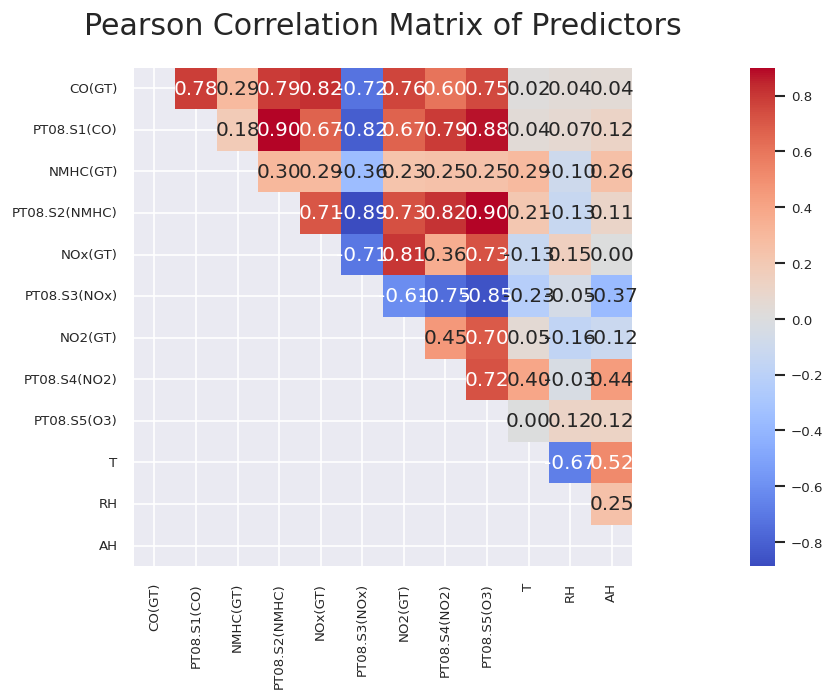

In [19]:

corr_predictors = X_train_z.corr(method="pearson")

mask = np.tril(np.ones_like(corr_predictors, dtype=bool))
sns.heatmap(corr_predictors, annot=True, fmt=".2f", cmap="coolwarm", square=True, mask=mask)
plt.title("Pearson Correlation Matrix of Predictors")
plt.tight_layout()
savefig("predictors_correlation_matrix")
plt.show()


iremos desconsiderar os valores de NMHC(GT)	por possuir muitos valores ausentes (90.35%)

## 2. Methods

This section describes the regression methods and evaluation techniques used in this study.

### 2.1 Setup and Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Preprocessing and model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Custom database module
import sys
sys.path.append('..')
from database.data_loader import DataLoader

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

ModuleNotFoundError: No module named 'seaborn'

### 2.2 Data Loading and Preparation

In [ ]:
# Initialize data loader
loader = DataLoader(data_path='../data')

# Load and prepare Air Quality dataset
# df = loader.load_csv('AirQualityUCI.csv', sep=';', decimal=',')

# For demonstration, create sample data
np.random.seed(42)
n_samples = 9358
df = pd.DataFrame({
    'CO(GT)': np.random.uniform(0.5, 5.0, n_samples),
    'PT08.S1(CO)': np.random.uniform(800, 1600, n_samples),
    'C6H6(GT)': np.random.uniform(2, 20, n_samples),
    'PT08.S2(NMHC)': np.random.uniform(600, 1400, n_samples),
    'NOx(GT)': np.random.uniform(50, 300, n_samples),
    'PT08.S3(NOx)': np.random.uniform(400, 1200, n_samples),
    'NO2(GT)': np.random.uniform(20, 150, n_samples),
    'PT08.S4(NO2)': np.random.uniform(800, 1800, n_samples),
    'PT08.S5(O3)': np.random.uniform(600, 1600, n_samples),
    'T': np.random.uniform(5, 35, n_samples),
    'RH': np.random.uniform(20, 80, n_samples),
    'AH': np.random.uniform(0.3, 1.8, n_samples)
})

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

### 2.3 Feature Engineering

In [ ]:
# Define target variable (e.g., predict CO concentration)
target_variable = 'CO(GT)'

# Select features for prediction
feature_cols = [col for col in df.columns if col != target_variable]

X = df[feature_cols]
y = df[target_variable]

print(f"Features: {feature_cols}")
print(f"Target: {target_variable}")
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

### 2.4 Train-Test Split

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

### 2.5 Feature Scaling

In [ ]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")
print(f"Mean of scaled features: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Std of scaled features: {X_train_scaled.std(axis=0).round(4)}")

### 2.6 Regression Models

We will implement and compare multiple regression algorithms.

#### 2.6.1 Linear Regression

In [ ]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"RMSE: {lr_rmse:.4f}")
print(f"MAE: {lr_mae:.4f}")
print(f"R²: {lr_r2:.4f}")

#### 2.6.2 Ridge Regression (L2 Regularization)

In [ ]:
# Ridge Regression with hyperparameter tuning
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
ridge_model = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_model.fit(X_train_scaled, y_train)

# Best model
best_ridge = ridge_model.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)

# Evaluation
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results:")
print(f"Best alpha: {ridge_model.best_params_['alpha']}")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"MAE: {ridge_mae:.4f}")
print(f"R²: {ridge_r2:.4f}")

#### 2.6.3 Lasso Regression (L1 Regularization)

In [ ]:
# Lasso Regression with hyperparameter tuning
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_model = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_model.fit(X_train_scaled, y_train)

# Best model
best_lasso = lasso_model.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_scaled)

# Evaluation
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Results:")
print(f"Best alpha: {lasso_model.best_params_['alpha']}")
print(f"RMSE: {lasso_rmse:.4f}")
print(f"MAE: {lasso_mae:.4f}")
print(f"R²: {lasso_r2:.4f}")

#### 2.6.4 Random Forest Regression

In [ ]:
# Random Forest Regression
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)  # Random Forest doesn't require scaling

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results:")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE: {rf_mae:.4f}")
print(f"R²: {rf_r2:.4f}")

#### 2.6.5 Gradient Boosting Regression

In [ ]:
# Gradient Boosting Regression
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluation
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regression Results:")
print(f"RMSE: {gb_rmse:.4f}")
print(f"MAE: {gb_mae:.4f}")
print(f"R²: {gb_r2:.4f}")

### 2.7 Model Comparison

In [ ]:
# Compare all models
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse, rf_rmse, gb_rmse],
    'MAE': [lr_mae, ridge_mae, lasso_mae, rf_mae, gb_mae],
    'R²': [lr_r2, ridge_r2, lasso_r2, rf_r2, gb_r2]
})

results = results.sort_values('R²', ascending=False)
print("\nModel Performance Comparison:")
print("=" * 80)
print(results.to_string(index=False))

### 2.8 Feature Importance Analysis

In [ ]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance from Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Important Features:")
print(feature_importance.head())

### 2.9 Residual Analysis

In [ ]:
# Residual plot for best model (e.g., Random Forest)
residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_rf, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Values', fontsize=12)
axes[0].set_ylabel('Predicted Values', fontsize=12)
axes[0].set_title('Predicted vs Actual', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residual plot
axes[1].scatter(y_pred_rf, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Results

*To be completed: Discuss your findings, including:*
- *Comparison of model performance metrics*
- *Best performing model and why*
- *Feature importance insights*
- *Residual analysis interpretation*
- *Model strengths and limitations*
- *Practical implications of the results*

## 4. Conclusions

*To be completed: Summarize the main findings, best model selection, and recommendations for air quality prediction.*

## 5. References

*To be completed: Add references to:*
- *UCI Machine Learning Repository*
- *Relevant papers on regression methods*
- *Air quality prediction studies*
- *Algorithm documentation*